In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 10
CHANNELS = 3

In [3]:
train_path = "C:/Users/Majid/Downloads/code/potato-disease/PlantVillage"

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [5]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 1722 images belonging to 3 classes.
Found 430 images belonging to 3 classes.


In [6]:
print(train_generator.class_indices)

{'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}


In [7]:
model = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(3, activation='softmax')
])

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 176s 3s/step - accuracy: 0.6783 - loss: 0.8232 - val_accuracy: 0.7488 - val_loss: 0.5987
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.8275 - loss: 0.4331 - val_accuracy: 0.8674 - val_loss: 0.3256
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.8821 - loss: 0.2785 - val_accuracy: 0.9233 - val_loss: 0.1926
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.8897 - loss: 0.2722 - val_accuracy: 0.8558 - val_loss: 0.3637
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 54s 990ms/step - accuracy: 0.9077 - loss: 0.2241 - val_accuracy: 0.9302 - val_loss: 0.1693
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 53s 987ms/step - accuracy: 0.9228 - loss: 0.2077 - val_accuracy: 0.9581 - val_loss: 0.1340
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 52s 961ms/step - accuracy: 0.9262 - loss: 0.1942 - val_accuracy: 0.9674 - val_loss: 0.1132
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 52s 960ms/step - accuracy: 0.9326 - loss: 0.1802 - val_accuracy: 0.948

In [10]:
model.save("saved_models/my_model.keras")

In [15]:
from PIL import Image
import numpy as np

img = Image.open(
    r"C:\Users\Majid\Downloads\code\potato-disease\PlantVillage\Potato___healthy\c6abf1da-b06f-4cd2-8af6-d68be5eff6f9___RS_HL 1766.JPG"
).convert("RGB")

img = img.resize((256,256))

img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, 0)

prediction = model.predict(img_array)

class_names = ['Potato___Early_blight','Potato___Late_blight','Potato___healthy']

print("Prediction:", class_names[np.argmax(prediction)])
print("Confidence:", np.max(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Prediction: Potato___healthy
Confidence: 0.9985291


Actual Class: Potato___healthy
Image: C:\Users\Majid\Downloads\code\potato-disease\PlantVillage\Potato___healthy\ad9b6cf4-e065-496d-91c7-5713ce14e19e___RS_HL 1926.JPG


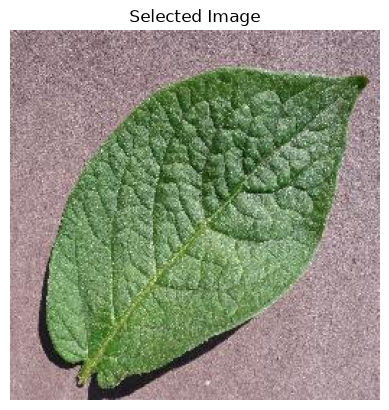

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
Predicted Class: Potato___healthy
Confidence: 0.9988372


In [16]:
import os
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Path to your dataset
dataset_path = r"C:\Users\Majid\Downloads\code\potato-disease\PlantVillage"

# Class names (must match training)
class_names = ['Potato___Early_blight','Potato___Late_blight','Potato___healthy']

# Pick random class folder
random_class = random.choice(class_names)

# Path of that class
class_path = os.path.join(dataset_path, random_class)

# Pick random image from that class
random_image_name = random.choice(os.listdir(class_path))
image_path = os.path.join(class_path, random_image_name)

print("Actual Class:", random_class)
print("Image:", image_path)

# Load image
img = Image.open(image_path).convert("RGB")
plt.imshow(img)
plt.title("Selected Image")
plt.axis("off")
plt.show()

# Preprocess
img = img.resize((256,256))
img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, 0)

# Predict
prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

print("Predicted Class:", predicted_class)
print("Confidence:", confidence)

In [27]:
import os
os.makedirs("saved_models", exist_ok=True)

In [28]:
model.save("saved_models/my_model.keras")

In [29]:
import os
print(os.listdir("saved_models"))

['1', 'my_model.keras']


In [30]:
import os
print(os.getcwd())

C:\Users\Majid\Downloads\code\potato-disease
